## Step 1: Import Libraries and Load Data
**Note:** Keep `COVID_Parcel_Business.csv` in the same folder as this notebook before running all cells.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

file_path = Path('COVID_Parcel_Business.csv')
df = pd.read_csv(file_path)

print("--- Dataset Info ---")
df.info()
print("\n--- Quick Checks ---")
print(f"Rows: {len(df):,}")
print(f"Customers: {df['FakeCustomerID'].nunique():,}")
print(f"Years: {sorted(df['THE_YEAR'].unique().tolist())}")
print(f"Week range: {df['THE_WEEK'].min()} to {df['THE_WEEK'].max()}")

display(df.head())

yearly_summary = df.groupby('THE_YEAR')['VOLUME'].agg(['sum', 'mean', 'median', 'count']).round(2)
display(yearly_summary)


--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 190719 entries, 0 to 190718
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   FakeCustomerID  190719 non-null  int64
 1   THE_YEAR        190719 non-null  int64
 2   THE_WEEK        190719 non-null  int64
 3   VOLUME          190719 non-null  int64
dtypes: int64(4)
memory usage: 5.8 MB

--- Quick Checks ---
Rows: 190,719
Customers: 1,061
Years: [2018, 2019, 2020, 2021]
Week range: 1 to 53


,FakeCustomerID,THE_YEAR,THE_WEEK,VOLUME
0,718117,2021,1,8
1,718117,2020,7,257
2,718117,2019,39,141
3,718117,2018,1,14
4,718117,2021,2,192


,sum,mean,median,count
THE_YEAR,,,,
2018,49099478,992.87,49.0,49452
2019,52823114,994.13,53.0,53135
2020,73475690,1428.49,69.0,51436
2021,48679668,1326.57,67.0,36696


## Step 2: Calculate Industry Standard Growth Rate (ISGR)
The compararison of **Weeks 1–15, 2020** against **Weeks 1–15, 2019**.


In [2]:
vol_2020_wk1_15 = df[(df['THE_YEAR'] == 2020) & (df['THE_WEEK'].between(1, 15))]['VOLUME'].sum()
vol_2019_wk1_15 = df[(df['THE_YEAR'] == 2019) & (df['THE_WEEK'].between(1, 15))]['VOLUME'].sum()

isgr = ((vol_2020_wk1_15 - vol_2019_wk1_15) / vol_2019_wk1_15) * 100

print(f"Total Volume (Weeks 1-15, 2019): {vol_2019_wk1_15:,}")
print(f"Total Volume (Weeks 1-15, 2020): {vol_2020_wk1_15:,}")
print(f"Industry Standard Growth Rate (ISGR): {isgr:.2f}%")


Total Volume (Weeks 1-15, 2019): 13,122,816
Total Volume (Weeks 1-15, 2020): 14,619,017
Industry Standard Growth Rate (ISGR): 11.40%


## Step 3: Identify When Volumes Were First Impacted by COVID-19
To answer the business question properly, We compared weekly parcel totals in 2019 and 2020.

### Candidate observation periods used in this notebook
- **Pre-COVID observation period:** Weeks **1–11** of 2020
- **COVID observation period:** Weeks **12–53** of 2020

### Why Week 12?
This is a judgement call based on both the data and the wider timeline:
- Week 11 still looks close to 2019 levels.
- Week 12 is the first clear post-announcement week where volume exceeds 2019 by roughly the ISGR threshold.
- The uplift becomes much stronger and sustained from Weeks 13–16 onward.

### Timeline context used to support the interpretation
- WHO characterised COVID-19 as a pandemic on **11 March 2020** [WHO](https://www.who.int/news-room/speeches/item/who-director-general-s-opening-remarks-at-the-media-briefing-on-covid-19---11-march-2020)
- Canada issued an official advisory to avoid non-essential travel abroad on **13 March 2020** [CBSA archived page](https://www.cbsa-asfc.gc.ca/transparency-transparence/pd-dp/bbp-rpp/hesa/2020-03-31/restrictions-eng.html)
- Canada-U.S. non-essential border restrictions were announced on **18 March 2020** and took effect on **21 March 2020** [Prime Minister of Canada](https://www.pm.gc.ca/en/news/news-releases/2020/03/20/prime-minister-announces-temporary-border-agreement-united-states)
- Mandatory isolation for returning travellers took effect on **25 March 2020** [CBSA archived page](https://www.cbsa-asfc.gc.ca/transparency-transparence/pd-dp/bbp-rpp/hesa/2020-03-31/restrictions-eng.html)


Selected COVID onset week for this notebook: Week 12


,Volume_2019,Volume_2020,Pct_Change_vs_2019
THE_WEEK,,,
9,803745.0,903362.0,12.39
10,792805.0,891398.0,12.44
11,879574.0,887335.0,0.88
12,864583.0,967436.0,11.90
13,853762.0,1084829.0,27.06
14,817979.0,1346802.0,64.65
15,874088.0,1480147.0,69.34
16,879169.0,2003866.0,127.93


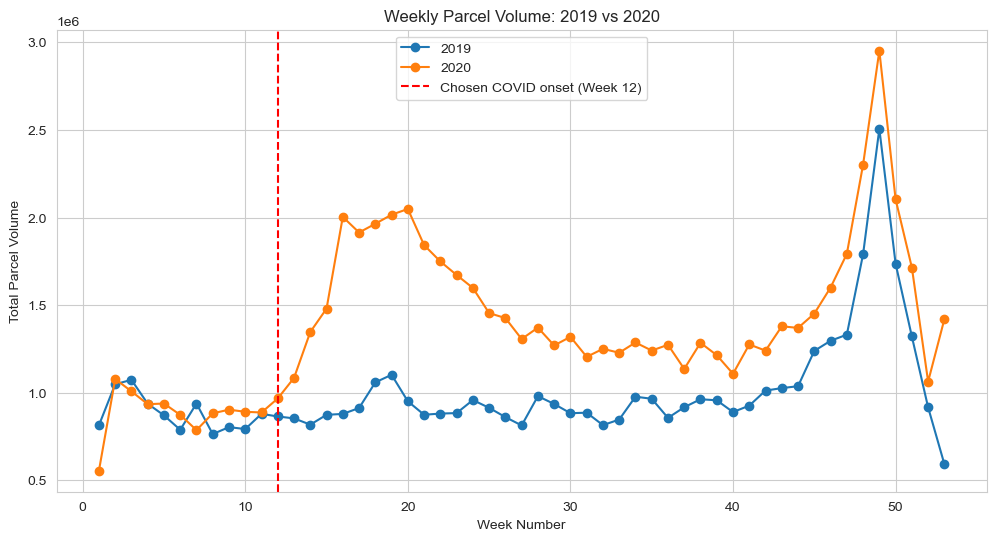

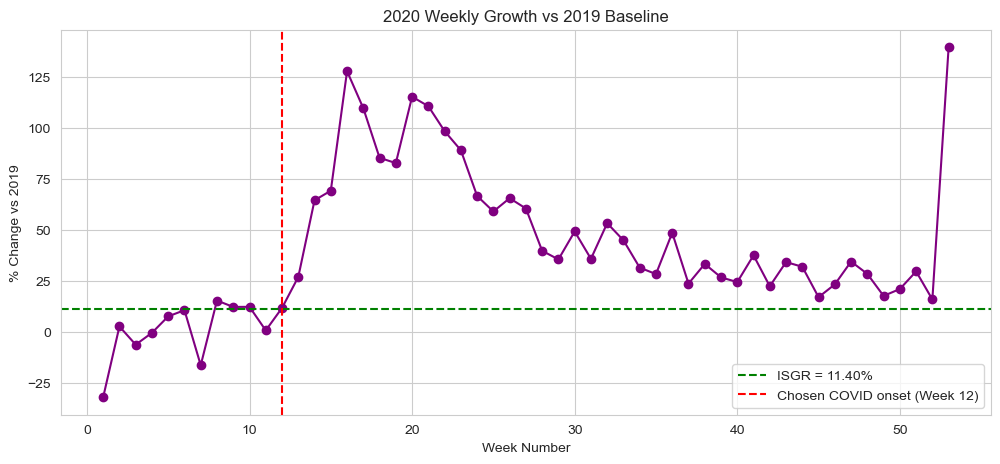

In [3]:
weekly_totals = df.groupby(['THE_YEAR', 'THE_WEEK'])['VOLUME'].sum().reset_index()
weekly_compare = weekly_totals.pivot(index='THE_WEEK', columns='THE_YEAR', values='VOLUME')[[2019, 2020]].copy()
weekly_compare.columns = ['Volume_2019', 'Volume_2020']
weekly_compare['Pct_Change_vs_2019'] = ((weekly_compare['Volume_2020'] - weekly_compare['Volume_2019']) / weekly_compare['Volume_2019']) * 100

onset_week = 12
print(f"Selected COVID onset week for this notebook: Week {onset_week}")
display(weekly_compare.loc[9:16].round(2))

plt.figure(figsize=(12, 6))
plt.plot(weekly_compare.index, weekly_compare['Volume_2019'], marker='o', label='2019')
plt.plot(weekly_compare.index, weekly_compare['Volume_2020'], marker='o', label='2020')
plt.axvline(onset_week, color='red', linestyle='--', label='Chosen COVID onset (Week 12)')
plt.title('Weekly Parcel Volume: 2019 vs 2020')
plt.xlabel('Week Number')
plt.ylabel('Total Parcel Volume')
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(weekly_compare.index, weekly_compare['Pct_Change_vs_2019'], marker='o', color='purple')
plt.axhline(isgr, color='green', linestyle='--', label=f'ISGR = {isgr:.2f}%')
plt.axvline(onset_week, color='red', linestyle='--', label='Chosen COVID onset (Week 12)')
plt.title('2020 Weekly Growth vs 2019 Baseline')
plt.xlabel('Week Number')
plt.ylabel('% Change vs 2019')
plt.legend()
plt.show()


## Step 4: Peak Season Comparison
Peak season as:
- **2019 peak season:** 4 Nov 2019 to 20 Jan 2020
- **2020 peak season:** 2 Nov 2020 to 17 Jan 2021

Because the dataset is weekly (not daily), we use the nearest full-week approximation:
- **2019 peak season approximation:** Weeks **45–53 of 2019** plus Weeks **1–4 of 2020**
- **2020 peak season approximation:** Weeks **45–53 of 2020** plus Weeks **1–4 of 2021**


2019 Peak Season Volume: 16,307,404
2020 Peak Season Volume: 20,753,199
Peak Season Change: 27.26%


,Peak_Season,Approx_Weeks,Total_Volume
0,2019 Peak Season,2019 W45-53 + 2020 W1-4,16307404
1,2020 Peak Season,2020 W45-53 + 2021 W1-4,20753199


C:\Users\DC\AppData\Local\Temp\ipykernel_169732\4159693200.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=peak_summary, x='Peak_Season', y='Total_Volume', palette='Blues_d')


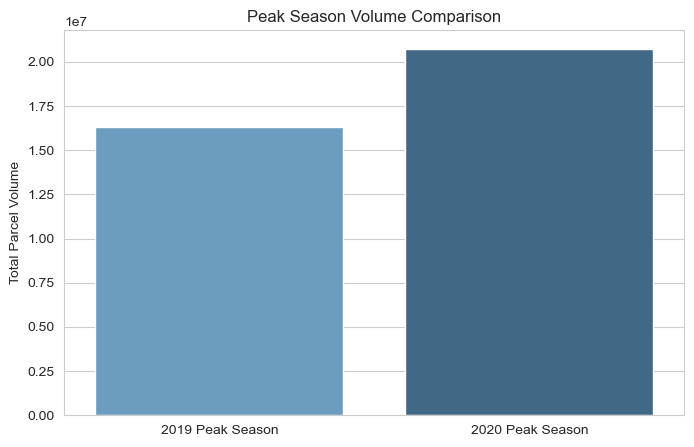

In [4]:
peak_2019 = df[((df['THE_YEAR'] == 2019) & (df['THE_WEEK'].between(45, 53))) |
               ((df['THE_YEAR'] == 2020) & (df['THE_WEEK'].between(1, 4)))]['VOLUME'].sum()

peak_2020 = df[((df['THE_YEAR'] == 2020) & (df['THE_WEEK'].between(45, 53))) |
               ((df['THE_YEAR'] == 2021) & (df['THE_WEEK'].between(1, 4)))]['VOLUME'].sum()

peak_change_pct = ((peak_2020 - peak_2019) / peak_2019) * 100

peak_summary = pd.DataFrame({
    'Peak_Season': ['2019 Peak Season', '2020 Peak Season'],
    'Approx_Weeks': ['2019 W45-53 + 2020 W1-4', '2020 W45-53 + 2021 W1-4'],
    'Total_Volume': [peak_2019, peak_2020]
})

print(f"2019 Peak Season Volume: {peak_2019:,}")
print(f"2020 Peak Season Volume: {peak_2020:,}")
print(f"Peak Season Change: {peak_change_pct:.2f}%")

display(peak_summary)

plt.figure(figsize=(8, 5))
sns.barplot(data=peak_summary, x='Peak_Season', y='Total_Volume', palette='Blues_d')
plt.title('Peak Season Volume Comparison')
plt.xlabel('')
plt.ylabel('Total Parcel Volume')
plt.show()


## Step 5: Categorise Customers During the COVID Observation Period
Here we compare:
- **Baseline window:** Weeks **12–53 of 2019**
- **COVID window:** Weeks **12–53 of 2020**

The assignment categories are applied as follows:
- **New Customer**: 0 volume in baseline window, but volume during COVID window
- **Lost Customer**: volume in baseline window, but 0 volume during COVID window
- **High Growth**: growth rate > ISGR
- **Stable**: growth rate between 0% and ISGR
- **Declining**: negative growth


--- Customer Category Counts ---


,Category,Customers,Percent
0,High Growth,588,55.47
1,Declining,370,34.91
2,Stable,77,7.26
3,Lost Customer,25,2.36


,Base_2019_COVID_Window,COVID_2020_Window,Growth_Rate,Category
FakeCustomerID,,,,
100771,1498,1413.0,-5.674232,Declining
102180,4559,4336.0,-4.891424,Declining
102643,2094,1134.0,-45.845272,Declining
102750,738,209.0,-71.680217,Declining
103308,76604,85596.0,11.738290,High Growth


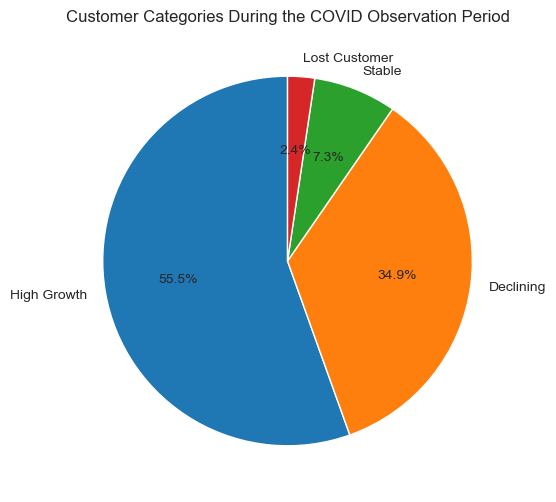

In [5]:
baseline_customer_volume = df[(df['THE_YEAR'] == 2019) & (df['THE_WEEK'].between(12, 53))].groupby('FakeCustomerID')['VOLUME'].sum()
covid_customer_volume = df[(df['THE_YEAR'] == 2020) & (df['THE_WEEK'].between(12, 53))].groupby('FakeCustomerID')['VOLUME'].sum()

customer_summary = pd.DataFrame({
    'Base_2019_COVID_Window': baseline_customer_volume,
    'COVID_2020_Window': covid_customer_volume
}).fillna(0)

customer_summary['Growth_Rate'] = np.where(
    customer_summary['Base_2019_COVID_Window'] > 0,
    ((customer_summary['COVID_2020_Window'] - customer_summary['Base_2019_COVID_Window']) / customer_summary['Base_2019_COVID_Window']) * 100,
    np.nan
)

def categorize_customer(row):
    if row['Base_2019_COVID_Window'] == 0 and row['COVID_2020_Window'] > 0:
        return 'New Customer'
    elif row['Base_2019_COVID_Window'] > 0 and row['COVID_2020_Window'] == 0:
        return 'Lost Customer'
    elif row['Growth_Rate'] > isgr:
        return 'High Growth'
    elif row['Growth_Rate'] >= 0:
        return 'Stable'
    else:
        return 'Declining'

customer_summary['Category'] = customer_summary.apply(categorize_customer, axis=1)

category_counts = customer_summary['Category'].value_counts().rename_axis('Category').reset_index(name='Customers')
category_counts['Percent'] = (category_counts['Customers'] / category_counts['Customers'].sum()) * 100

print("--- Customer Category Counts ---")
display(category_counts.round(2))
display(customer_summary.head())

plt.figure(figsize=(8, 6))
plt.pie(category_counts['Customers'], labels=category_counts['Category'], autopct='%1.1f%%', startangle=90)
plt.title('Customer Categories During the COVID Observation Period')
plt.show()


## Step 6: Customer Group Analysis (Proxy Groups)
The assignment asks for analysis by customer groups such as Enterprise and Large. However, the provided dataset does not include an official customer-group field.

To make a transparent and defensible adjustment, we create **proxy customer groups** using 2019 annual parcel-volume quartiles:
- **Small (Proxy)**
- **Medium (Proxy)**
- **Large (Proxy)**
- **Enterprise-like (Proxy)**

These are not the company's official commercial groups. They are an analytical workaround based only on the available data.


2019 annual-volume quartiles -> Q1: 1612, Median: 2969, Q3: 7218
--- Category % by Proxy Group ---


Category,Declining,High Growth,Lost Customer,Stable
Proxy_Group,,,,
Enterprise-like (Proxy),34.72,54.72,1.13,9.43
Large (Proxy),34.47,56.82,2.65,6.06
Medium (Proxy),35.47,55.09,1.89,7.55
Small (Proxy),34.96,55.26,3.76,6.02


<Figure size 1200x600 with 0 Axes>

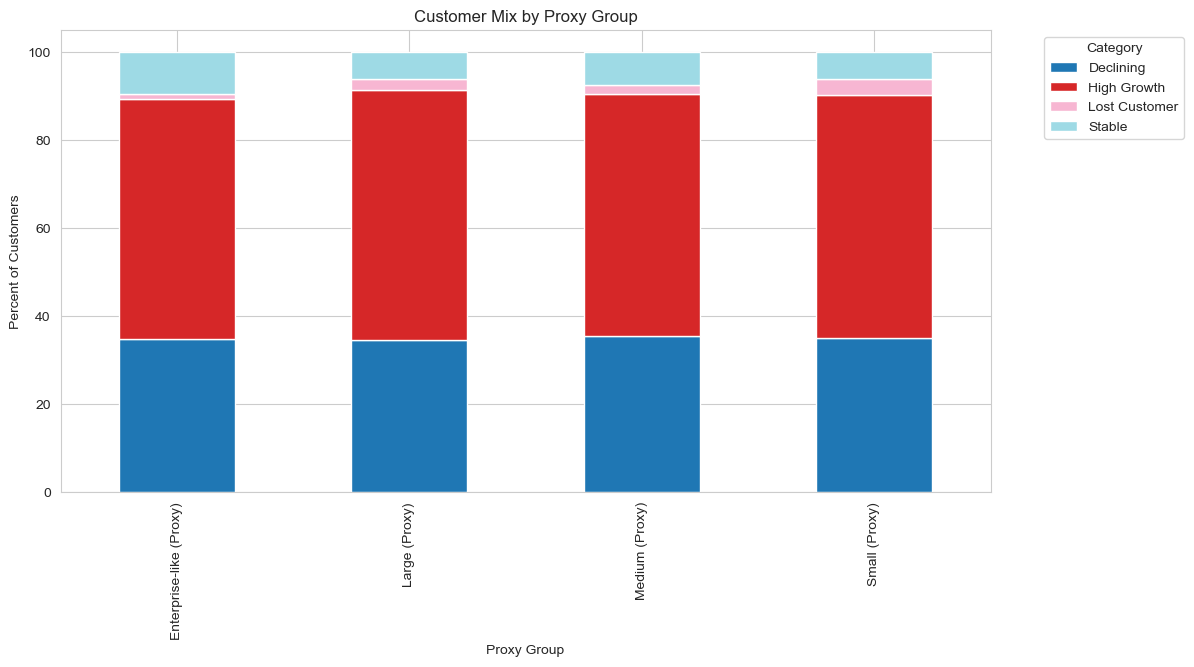

In [6]:
annual_2019_volume = df[df['THE_YEAR'] == 2019].groupby('FakeCustomerID')['VOLUME'].sum().rename('Annual_2019_Volume')
customer_summary = customer_summary.join(annual_2019_volume, how='left').fillna({'Annual_2019_Volume': 0})

q1, q2, q3 = annual_2019_volume.quantile([0.25, 0.50, 0.75]).tolist()
print(f"2019 annual-volume quartiles -> Q1: {q1:.0f}, Median: {q2:.0f}, Q3: {q3:.0f}")

def assign_proxy_group(volume):
    if volume <= q1:
        return 'Small (Proxy)'
    elif volume <= q2:
        return 'Medium (Proxy)'
    elif volume <= q3:
        return 'Large (Proxy)'
    else:
        return 'Enterprise-like (Proxy)'

customer_summary['Proxy_Group'] = customer_summary['Annual_2019_Volume'].apply(assign_proxy_group)

proxy_group_mix = pd.crosstab(customer_summary['Proxy_Group'], customer_summary['Category'], normalize='index') * 100
proxy_group_mix = proxy_group_mix.round(2)

print("--- Category % by Proxy Group ---")
display(proxy_group_mix)

plt.figure(figsize=(12, 6))
proxy_group_mix.plot(kind='bar', stacked=True, colormap='tab20', figsize=(12, 6))
plt.title('Customer Mix by Proxy Group')
plt.xlabel('Proxy Group')
plt.ylabel('Percent of Customers')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


## Step 7: Overall Impact on Volume and Estimated Revenue by Proxy Group
Since discount tiers were not supplied, revenue is estimated using the assignment's **base price of $22 per parcel** only.

This means:
- the results below are useful for directional analysis,
- but they should be treated as **gross estimated revenue**, not net revenue after discounts.


--- Volume and Estimated Revenue by Proxy Group ---


,Proxy_Group,Volume_2019_Window,Volume_2020_Window,Estimated_Revenue_2019,Estimated_Revenue_2020,Volume_Change_%,Estimated_Revenue_Change_%
0,Enterprise-like (Proxy),41378529,60824352.0,910327638,1.338136e+09,46.99,46.99
1,Large (Proxy),983550,1567159.0,21638100,3.447750e+07,59.34,59.34
2,Medium (Proxy),474084,827527.0,10429848,1.820559e+07,74.55,74.55
3,Small (Proxy),274547,516849.0,6040034,1.137068e+07,88.26,88.26


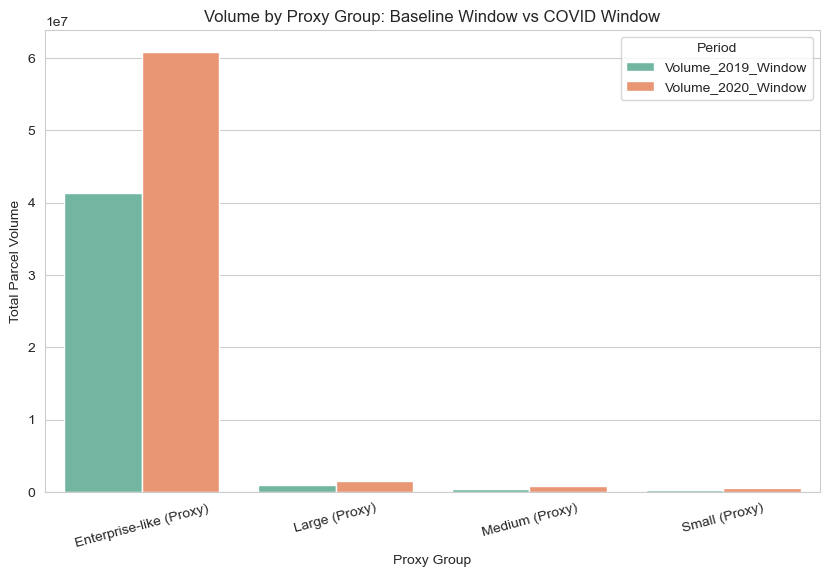

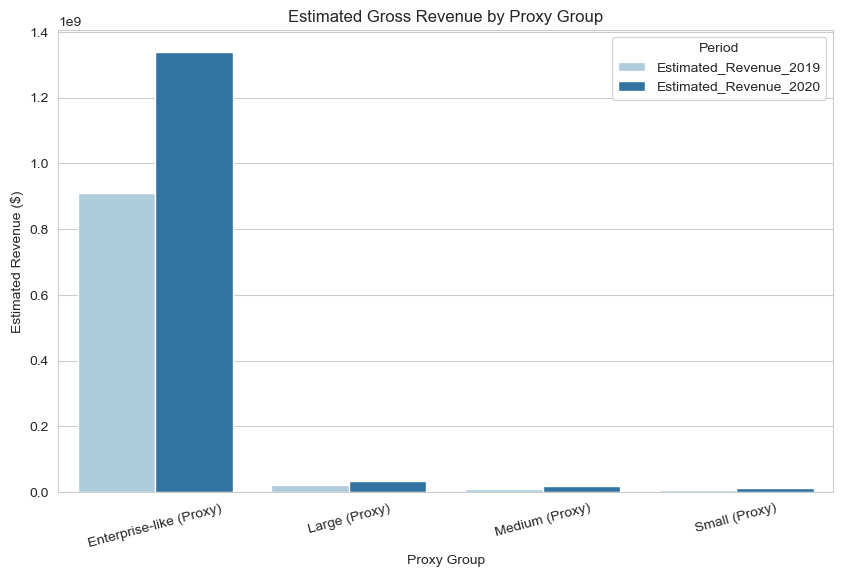

In [7]:
volume_by_customer_2019_window = df[(df['THE_YEAR'] == 2019) & (df['THE_WEEK'].between(12, 53))].groupby('FakeCustomerID')['VOLUME'].sum().rename('Volume_2019_Window')
volume_by_customer_2020_window = df[(df['THE_YEAR'] == 2020) & (df['THE_WEEK'].between(12, 53))].groupby('FakeCustomerID')['VOLUME'].sum().rename('Volume_2020_Window')

customer_summary = customer_summary.join(volume_by_customer_2019_window, how='left').join(volume_by_customer_2020_window, how='left').fillna({
    'Volume_2019_Window': 0,
    'Volume_2020_Window': 0
})

customer_summary['Estimated_Revenue_2019'] = customer_summary['Volume_2019_Window'] * 22
customer_summary['Estimated_Revenue_2020'] = customer_summary['Volume_2020_Window'] * 22

proxy_group_summary = customer_summary.groupby('Proxy_Group').agg({
    'Volume_2019_Window': 'sum',
    'Volume_2020_Window': 'sum',
    'Estimated_Revenue_2019': 'sum',
    'Estimated_Revenue_2020': 'sum'
}).reset_index()

proxy_group_summary['Volume_Change_%'] = ((proxy_group_summary['Volume_2020_Window'] - proxy_group_summary['Volume_2019_Window']) / proxy_group_summary['Volume_2019_Window']) * 100
proxy_group_summary['Estimated_Revenue_Change_%'] = ((proxy_group_summary['Estimated_Revenue_2020'] - proxy_group_summary['Estimated_Revenue_2019']) / proxy_group_summary['Estimated_Revenue_2019']) * 100
proxy_group_summary = proxy_group_summary.sort_values('Volume_2020_Window', ascending=False)

print("--- Volume and Estimated Revenue by Proxy Group ---")
display(proxy_group_summary.round(2))

plt.figure(figsize=(10, 6))
plot_data = proxy_group_summary.melt(id_vars='Proxy_Group', value_vars=['Volume_2019_Window', 'Volume_2020_Window'], var_name='Period', value_name='Volume')
sns.barplot(data=plot_data, x='Proxy_Group', y='Volume', hue='Period', palette='Set2')
plt.title('Volume by Proxy Group: Baseline Window vs COVID Window')
plt.xlabel('Proxy Group')
plt.ylabel('Total Parcel Volume')
plt.xticks(rotation=15)
plt.show()

plt.figure(figsize=(10, 6))
plot_rev = proxy_group_summary.melt(id_vars='Proxy_Group', value_vars=['Estimated_Revenue_2019', 'Estimated_Revenue_2020'], var_name='Period', value_name='Revenue')
sns.barplot(data=plot_rev, x='Proxy_Group', y='Revenue', hue='Period', palette='Paired')
plt.title('Estimated Gross Revenue by Proxy Group')
plt.xlabel('Proxy Group')
plt.ylabel('Estimated Revenue ($)')
plt.xticks(rotation=15)
plt.show()


## Step 8: Additional Descriptive Statistics and Business Summary
This section pulls together a few final views that are useful in an executive presentation.


,THE_YEAR,VOLUME,YoY_Change_%
0,2018,49099478,NaN
1,2019,52823114,7.58
2,2020,73475690,39.10
3,2021,48679668,-33.75


C:\Users\DC\AppData\Local\Temp\ipykernel_169732\393965201.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=total_volume_by_year, x='THE_YEAR', y='VOLUME', palette='crest')


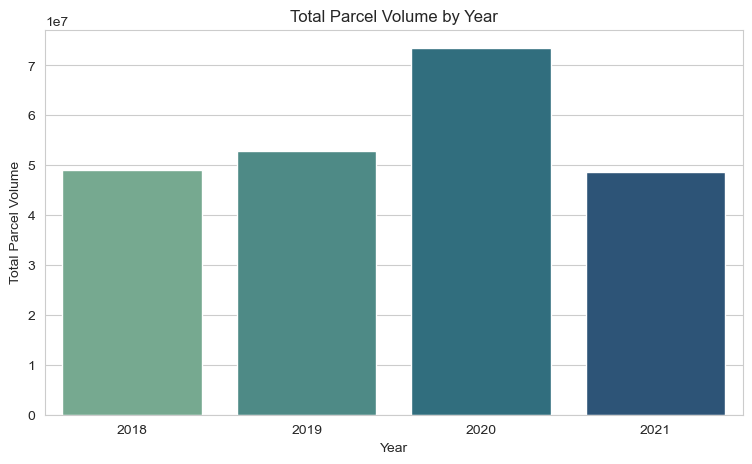

--- Key Summary Points ---
- ISGR (Weeks 1-15, 2020 vs 2019): 11.40%
- Chosen COVID onset week: Week 12
- Peak season change (approx.): 27.26%
- High Growth customers: 588
- Stable customers: 77
- Declining customers: 370
- Lost customers: 25


In [8]:
total_volume_by_year = df.groupby('THE_YEAR')['VOLUME'].sum().reset_index()
total_volume_by_year['YoY_Change_%'] = total_volume_by_year['VOLUME'].pct_change() * 100

display(total_volume_by_year.round(2))

plt.figure(figsize=(9, 5))
sns.barplot(data=total_volume_by_year, x='THE_YEAR', y='VOLUME', palette='crest')
plt.title('Total Parcel Volume by Year')
plt.xlabel('Year')
plt.ylabel('Total Parcel Volume')
plt.show()

summary_points = [
    f"ISGR (Weeks 1-15, 2020 vs 2019): {isgr:.2f}%",
    f"Chosen COVID onset week: Week {onset_week}",
    f"Peak season change (approx.): {peak_change_pct:.2f}%",
    f"High Growth customers: {int((customer_summary['Category'] == 'High Growth').sum())}",
    f"Stable customers: {int((customer_summary['Category'] == 'Stable').sum())}",
    f"Declining customers: {int((customer_summary['Category'] == 'Declining').sum())}",
    f"Lost customers: {int((customer_summary['Category'] == 'Lost Customer').sum())}"
]

print("--- Key Summary Points ---")
for point in summary_points:
    print('-', point)


## Step 9: Export Clean Summary Tables for Power BI / Excel
To make the dashboard easier to update, I export the key summary tables below.


In [9]:
output_dir = Path('exported_summary_tables')
output_dir.mkdir(exist_ok=True)

weekly_compare_export = weekly_compare.reset_index()
category_counts_export = category_counts.copy()
proxy_group_mix_export = proxy_group_mix.reset_index()
peak_summary_export = peak_summary.copy()
customer_summary_export = customer_summary.reset_index()
proxy_group_summary_export = proxy_group_summary.copy()

a = output_dir / 'weekly_compare_2019_2020.csv'
b = output_dir / 'customer_category_counts.csv'
c = output_dir / 'proxy_group_mix_percent.csv'
d = output_dir / 'peak_season_summary.csv'
e = output_dir / 'customer_level_summary.csv'
f = output_dir / 'proxy_group_summary.csv'

weekly_compare_export.to_csv(a, index=False)
category_counts_export.to_csv(b, index=False)
proxy_group_mix_export.to_csv(c, index=False)
peak_summary_export.to_csv(d, index=False)
customer_summary_export.to_csv(e, index=False)
proxy_group_summary_export.to_csv(f, index=False)

print("Saved files:")
for path in [a, b, c, d, e, f]:
    print('-', path)


Saved files:
- exported_summary_tables\weekly_compare_2019_2020.csv
- exported_summary_tables\customer_category_counts.csv
- exported_summary_tables\proxy_group_mix_percent.csv
- exported_summary_tables\peak_season_summary.csv
- exported_summary_tables\customer_level_summary.csv
- exported_summary_tables\proxy_group_summary.csv


## Step 10: Final Interpretation, Recommendations, and Limitations
### Main findings
- The industry baseline growth rate before the major COVID demand shock was **11.40%**.
- A visible and sustained change in weekly parcel activity appears from around **Week 12 of 2020**, with much sharper acceleration from Weeks 13–16.
- Using a full-week approximation, the **2020 peak season was stronger than the 2019 peak season**.
- Most customers fall into the **High Growth** or **Declining** categories, which suggests that COVID created both winners and losers across the client base.
- The highest-volume proxy group carries most of the parcel volume and most of the estimated gross revenue.

### Recommendations
- Retain high-growth customers through service-level protection and account management.
- Review declining and lost customers for sector-specific recovery strategies.
- Plan capacity more carefully for future demand spikes, especially in peak season.
- If ABC Company can access official customer-group labels and discount contracts, the analysis should be rerun to replace the proxy-group and gross-revenue assumptions.

### Limitation statement
This notebook is transparent about two data gaps:
1. **Official customer groups were not provided**, so quartile-based proxy groups were used instead.
2. **Discount percentages were not provided**, so revenue was estimated using the base parcel price only.

That makes the analytical direction useful, but the customer-group and revenue sections should be presented as **well-documented estimates**, not as final audited commercial figures.
